In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as la

In [2]:
X01 = np.array([[0, 1, 0],
                [1, 0, 0],
                [0, 0, 0]], dtype = complex)
    
Y01 = np.array([[0, -1j, 0],
                [1j, 0, 0],
                [0, 0, 0]], dtype = complex)
    
X12 = np.array([[0, 0, 0],
                [0, 0, 1],
                [0, 1, 0]], dtype = complex)
    
Y12 = np.array([[0, 0, 0],
                [0, 0, -1j],
                [0, 1j, 0]], dtype = complex)

In [22]:
p0 = 0.9
rho0 = np.array([[p0, 0, 0],
                [0, 1-p0, 0],
                [0, 0, 0]], 
               dtype = complex)

In [23]:
w01 = 2*np.pi * 4.391e9 # GHz
anh = 2*np.pi * -0.181e9 # GHz
lamb01 = 1.0
lamb12 = 2**(1/2)

w12 = w01 + anh

In [24]:
def constantWF(_t):
    return 1
def gaussianWF(_t, _mu, _sigma):
    return np.exp(-(_t - _mu)**2/(2*_sigma**2))

In [25]:
def get_H(_t, _wd, _V0, _phi, _s):
    dw01 = w01 - _wd
    dw12 = w12 - _wd
    I = np.cos(_phi)
    Q = np.sin(_phi)
    return (_V0/2) * _s(_t) * (lamb01 * ( (-I * np.sin(dw01 * _t) + Q * np.cos(dw01 * _t)) * Y01
                                       -(I * np.cos(dw01 * _t) + Q * np.sin(dw01 * _t)) * X01)
                             + lamb12 * ( (-I * np.sin(dw12 * _t) + Q * np.cos(dw12 * _t)) * Y12
                                       -(I * np.cos(dw12 * _t) + Q * np.sin(dw12 * _t)) * X12))
def get_U(_t, _dt, _wd, _V0, _phi, _s):
    return la.expm(-1j * get_H(_t, _wd, _V0, _phi, _s) * _dt)

In [26]:
T = 200e-9
V0 = np.pi/(T * lamb01)
wd = w01
phi = 0
def s(_t):
    return constantWF(_t)
    

steps = 1000
times = np.linspace(0, T, steps)
dt = T/float(steps)

rho = rho0.copy()
pops = np.zeros((3, steps))

for i in range(steps):
    U = get_U(times[i], dt, wd, V0, phi, s)
    rho = np.matmul(U, np.matmul(rho, U.T.conj()))
    pops[:, i] = np.diag(np.real(rho))
    

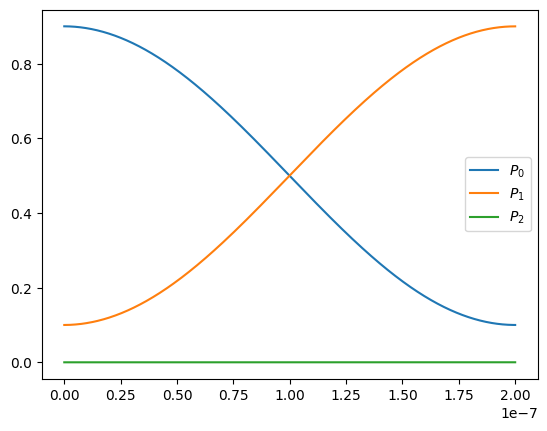

In [27]:
plt.plot(times, pops[0,:], label = r'$P_0$')
plt.plot(times, pops[1,:], label = r'$P_1$')
plt.plot(times, pops[2,:], label = r'$P_2$')
plt.legend()

In [28]:
def simulate(_steps, _wd, _T, _V0, _phi, _s):
    _times = np.linspace(0, _T, _steps)
    _dt = _T/float(_steps)
    _rho = rho0.copy()
    U = np.array([[1, 0, 0],
                  [0, 1, 0],
                  [0, 0, 1]])
    for jt in range(_steps):
        U = get_U(_times[jt], _dt, _wd, _V0, _phi, _s)@U
    _rho = U @ _rho @ U.T.conj()
    return np.diag(np.real(_rho))
    

In [40]:
from tqdm import tqdm
T = 50e-9
V0 = 3*np.pi/(T*lamb01)
phi = 0.0
def s(_t):
    return gaussianWF(_t, T/2, 12e-9)
tsteps = 500

dw_steps = 1000
dw_lim = 2*np.pi * 0.25e9
dw = np.linspace(-dw_lim, dw_lim, dw_steps)

In [41]:
pops = np.zeros((3, dw_steps))
for i in tqdm(range(dw_steps)):
    pops[:,i] = simulate(tsteps, w01+ dw[i], T, V0, phi, s)


100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:37<00:00, 26.52it/s]


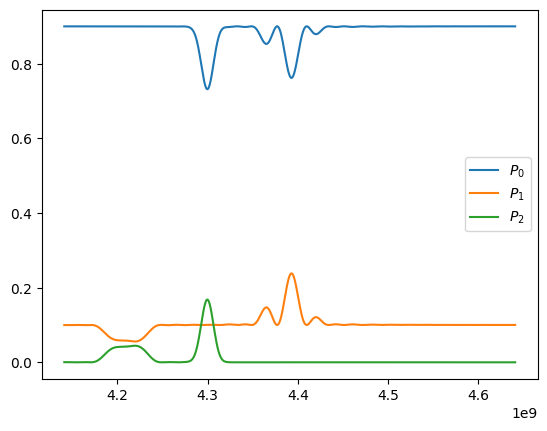

In [42]:
freqs = (w01+dw)/(2*np.pi)
plt.plot(freqs, pops[0,:], label = r'$P_0$')
plt.plot(freqs, pops[1,:], label = r'$P_1$')
plt.plot(freqs, pops[2,:], label = r'$P_2$')
plt.legend()

In [36]:
w12/(2*np.pi)

4209999999.9999995